# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [4]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262.0,19.0,7.0,Sat,AKLDEL,New Zealand,1.0,0.0,0.0,5.52,0.0
1,1,Internet,RoundTrip,112.0,20.0,3.0,Sat,AKLDEL,New Zealand,0.0,0.0,0.0,5.52,0.0
2,2,Internet,RoundTrip,243.0,22.0,17.0,Wed,AKLDEL,India,1.0,1.0,0.0,5.52,0.0
3,1,Internet,RoundTrip,96.0,31.0,4.0,Sat,AKLDEL,New Zealand,0.0,0.0,1.0,5.52,0.0
4,2,Internet,RoundTrip,68.0,22.0,15.0,Wed,AKLDEL,India,1.0,0.0,1.0,5.52,0.0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16382 entries, 0 to 16381
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         16382 non-null  int64  
 1   sales_channel          16382 non-null  object 
 2   trip_type              16382 non-null  object 
 3   purchase_lead          16381 non-null  float64
 4   length_of_stay         16381 non-null  float64
 5   flight_hour            16381 non-null  float64
 6   flight_day             16381 non-null  object 
 7   route                  16381 non-null  object 
 8   booking_origin         16381 non-null  object 
 9   wants_extra_baggage    16381 non-null  float64
 10  wants_preferred_seat   16381 non-null  float64
 11  wants_in_flight_meals  16381 non-null  float64
 12  flight_duration        16381 non-null  float64
 13  booking_complete       16381 non-null  float64
dtypes: float64(8), int64(1), object(5)
memory usage: 1.7+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [6]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri', nan], dtype=object)

In [7]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [8]:
df["flight_day"].unique()

array([ 6.,  3.,  4.,  1.,  7.,  2.,  5., nan])

In [9]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,16382.000000,16381.000000,16381.000000,16381.000000,16381.000000,16381.000000,16381.000000,16381.000000,16381.000000,16381.000000
mean,1.472287,86.618094,40.267932,8.891032,3.830169,0.767413,0.306453,0.487211,7.753264,0.106526
std,0.865432,86.515951,40.534052,5.482142,1.993878,0.422494,0.461034,0.499852,1.426825,0.308519
min,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,23.000000,21.000000,5.000000,2.000000,1.000000,0.000000,0.000000,6.620000,0.000000
50%,1.000000,56.000000,28.000000,9.000000,4.000000,1.000000,0.000000,0.000000,8.580000,0.000000
75%,2.000000,120.000000,42.000000,12.000000,6.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,641.000000,778.000000,23.000000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

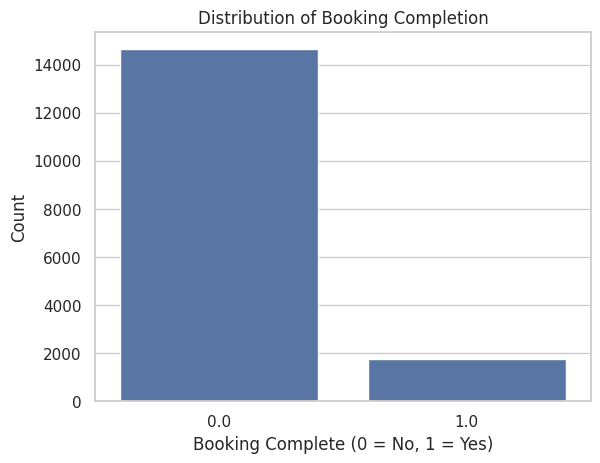

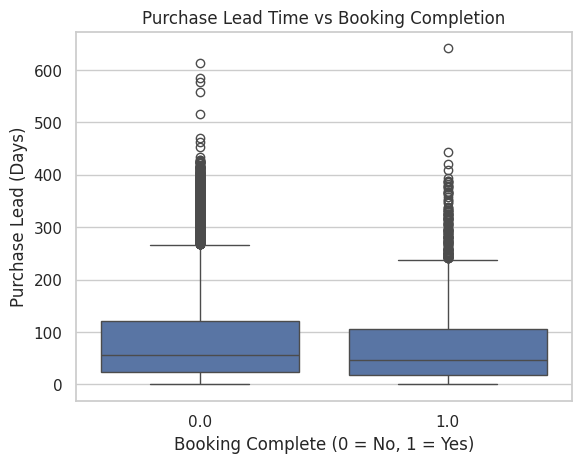

<ipython-input-19-7bbce79f5309>:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='booking_complete', y='flight_duration', data=df, ci=None)


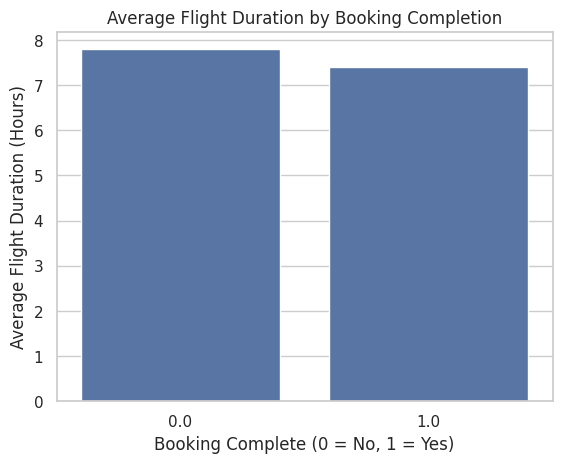

In [19]:

# Set the style for seaborn
sns.set(style="whitegrid")

# Visualize the distribution of the target variable
sns.countplot(x='booking_complete', data=df)
plt.title('Distribution of Booking Completion')
plt.xlabel('Booking Complete (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Visualize the relationship between purchase lead and booking completion
sns.boxplot(x='booking_complete', y='purchase_lead', data=df)
plt.title('Purchase Lead Time vs Booking Completion')
plt.xlabel('Booking Complete (0 = No, 1 = Yes)')
plt.ylabel('Purchase Lead (Days)')
plt.show()

# Visualize the average flight duration by booking completion
sns.barplot(x='booking_complete', y='flight_duration', data=df, ci=None)
plt.title('Average Flight Duration by Booking Completion')
plt.xlabel('Booking Complete (0 = No, 1 = Yes)')
plt.ylabel('Average Flight Duration (Hours)')
plt.show()

Treat outliers

In [21]:

# Calculate IQR
Q1 = df['booking_complete'].quantile(0.25)
Q3 = df['booking_complete'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers (optional: or keep them)
df_no_outliers = df[(df['booking_complete'] >= lower_bound) & (df['booking_complete'] <= upper_bound)]


Normalized

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_no_outliers['booking_complete_normalized'] = scaler.fit_transform(df_no_outliers[['booking_complete']])

<ipython-input-22-c5c4d787525c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['booking_complete_normalized'] = scaler.fit_transform(df_no_outliers[['booking_complete']])


In [11]:
# Convert categorical variables using one-hot encoding
df = pd.get_dummies(df, columns=['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin'], drop_first=True)

# Create new features based on existing ones
# Example: Categorizing purchase lead time
bins = [0, 3, 7, 14, 30, 60, 90, float('inf')]
labels = ['0-3 days', '4-7 days', '8-14 days', '15-30 days', '31-60 days', '61-90 days', '90+ days']
df['purchase_lead_category'] = pd.cut(df['purchase_lead'], bins=bins, labels=labels)

In [12]:
# Convert the new categorical feature into dummy variables
df = pd.get_dummies(df, columns=['purchase_lead_category'], drop_first=True)

In [47]:
# Example: Binning flight hours
df['flight_hour_category'] = pd.cut(df['flight_hour'], bins=[0, 6, 12, 18, 24], labels=['Night', 'Morning', 'Afternoon', 'Evening'])
df = pd.get_dummies(df, columns=['flight_hour_category'], drop_first=True)

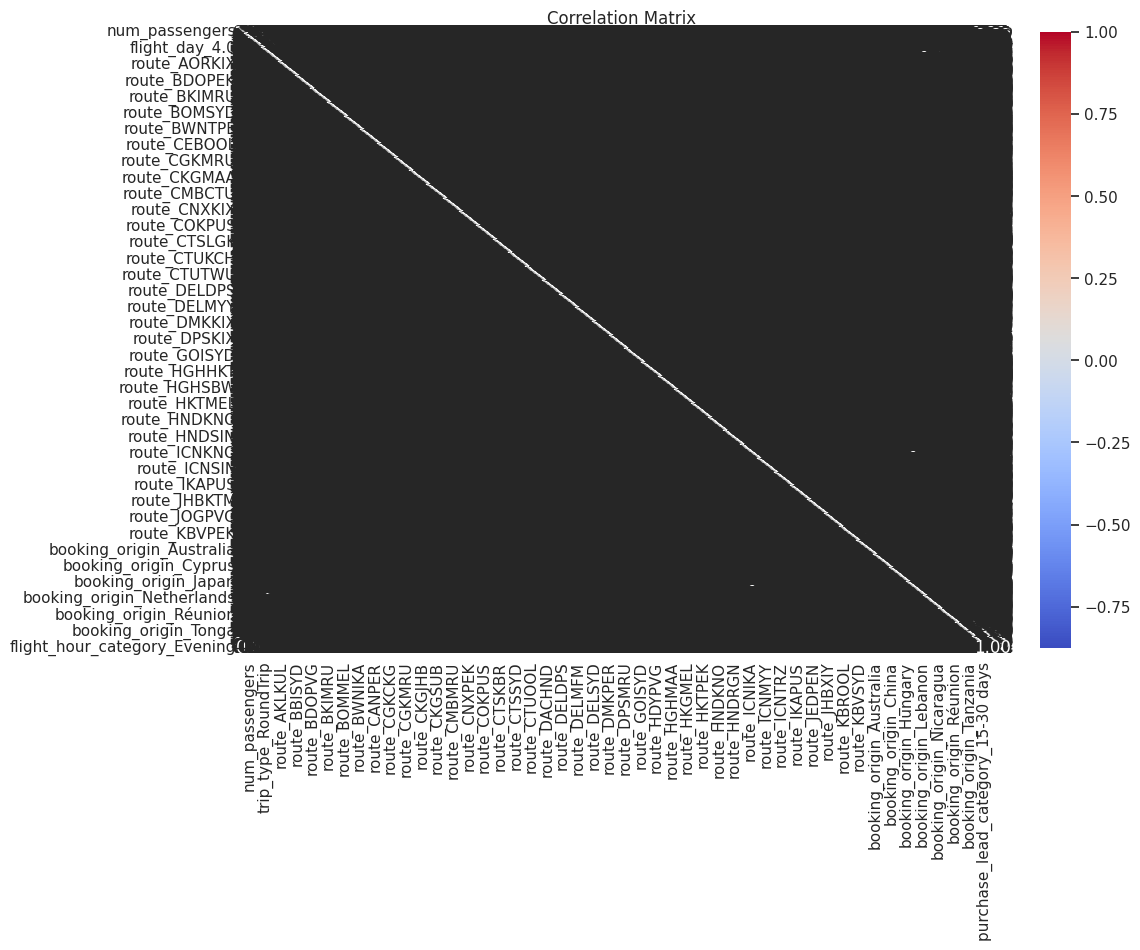

In [14]:
# Correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

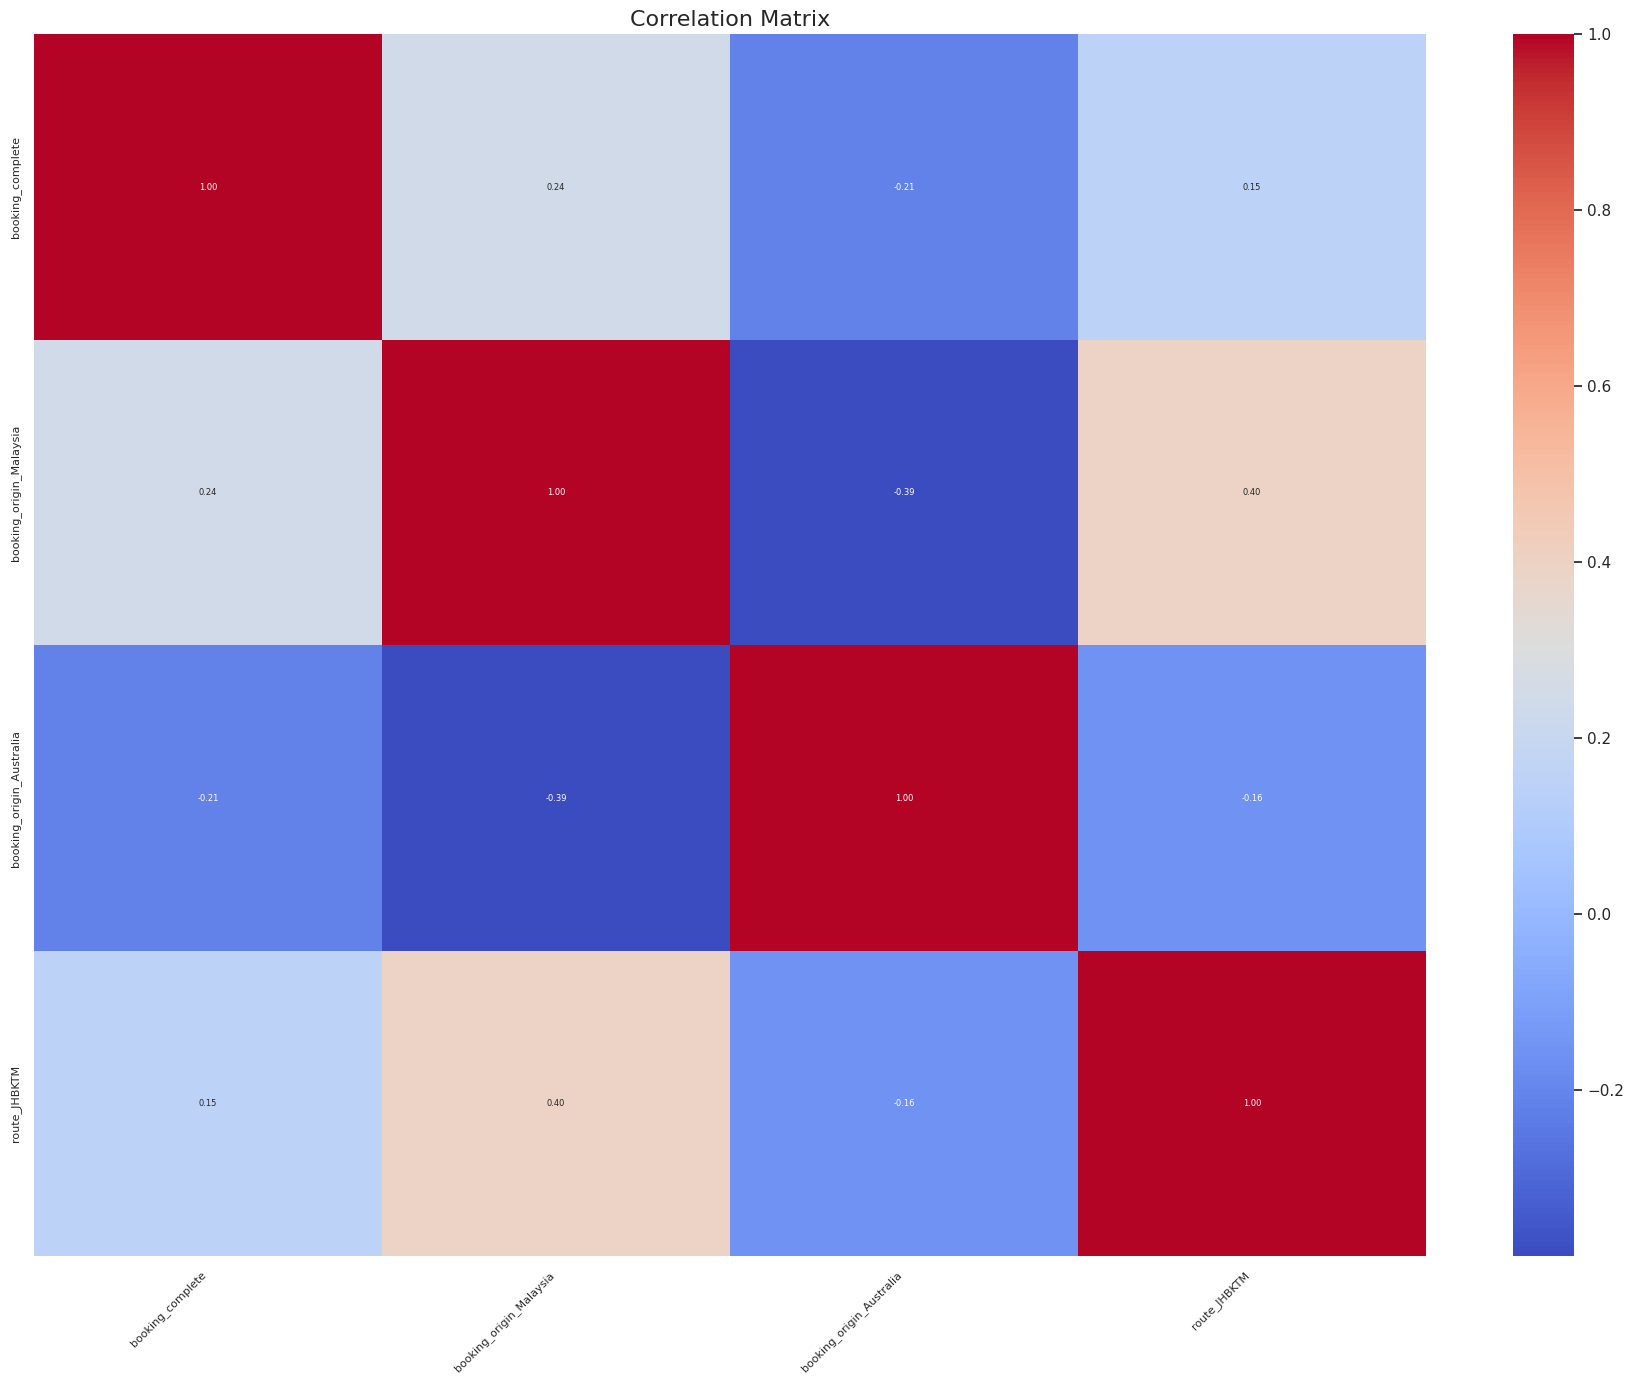

In [48]:
# Compute correlation matrix
correlation_matrix = df.corr()

# OPTIONAL: focus on variables most correlated with the target variable
corr_target = correlation_matrix['booking_complete'].abs().sort_values(ascending=False)
top_features = corr_target[corr_target > 0.1].index  # adjust threshold as needed
correlation_matrix = df[top_features].corr()

# Plot
plt.figure(figsize=(18, 14))  # Increased figure size
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 6}  # Smaller font for annotations
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [49]:
# Only show correlations > 0.3 or < -0.3 with the target variable
important_corrs = correlation_matrix['booking_complete'][abs(correlation_matrix['booking_complete']) > 0.3]
print(important_corrs.sort_values(ascending=False))

booking_complete    1.0
Name: booking_complete, dtype: float64


In [36]:

# Define features and target variable
X = df.drop('booking_complete', axis=1)  # Features
y = df['booking_complete']  # Target variable

# Fill missing values with the most frequent value (mode)
y = y.fillna(y.mode()[0])
y, y.isnull().sum()


(0        0.0
 1        0.0
 2        0.0
 3        0.0
 4        0.0
         ... 
 16377    0.0
 16378    0.0
 16379    0.0
 16380    0.0
 16381    0.0
 Name: booking_complete, Length: 16382, dtype: float64,
 np.int64(0))

In [37]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Fit the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

In [39]:

# Print evaluation metrics
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94      2919
         1.0       0.58      0.08      0.15       358

    accuracy                           0.89      3277
   macro avg       0.74      0.54      0.54      3277
weighted avg       0.86      0.89      0.86      3277

Accuracy: 0.8931949954226427


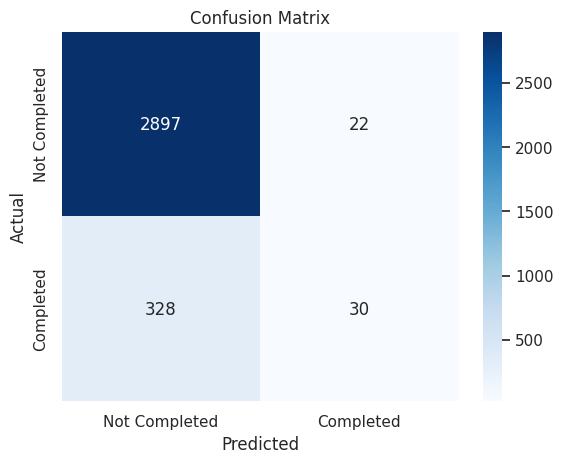

In [40]:

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Completed', 'Completed'], yticklabels=['Not Completed', 'Completed'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
from sklearn.model_selection import train_test_split, cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average Cross-Validation Accuracy: {cv_scores.mean()}")

Cross-Validation Scores: [0.34269149 0.53982301 0.89346764 0.89285714 0.79395604]
Average Cross-Validation Accuracy: 0.6925590650491473


In [42]:
import numpy as np

# Get feature importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

In [43]:
# Select the top N features (e.g., top 10)
top_n = 10
top_features = X.columns[indices][:top_n]

print("Top features:", top_features)

Top features: Index(['purchase_lead', 'length_of_stay', 'flight_hour', 'num_passengers',
       'flight_duration', 'booking_origin_Malaysia', 'wants_in_flight_meals',
       'flight_hour_category_Morning', 'wants_preferred_seat',
       'booking_origin_Australia'],
      dtype='object')


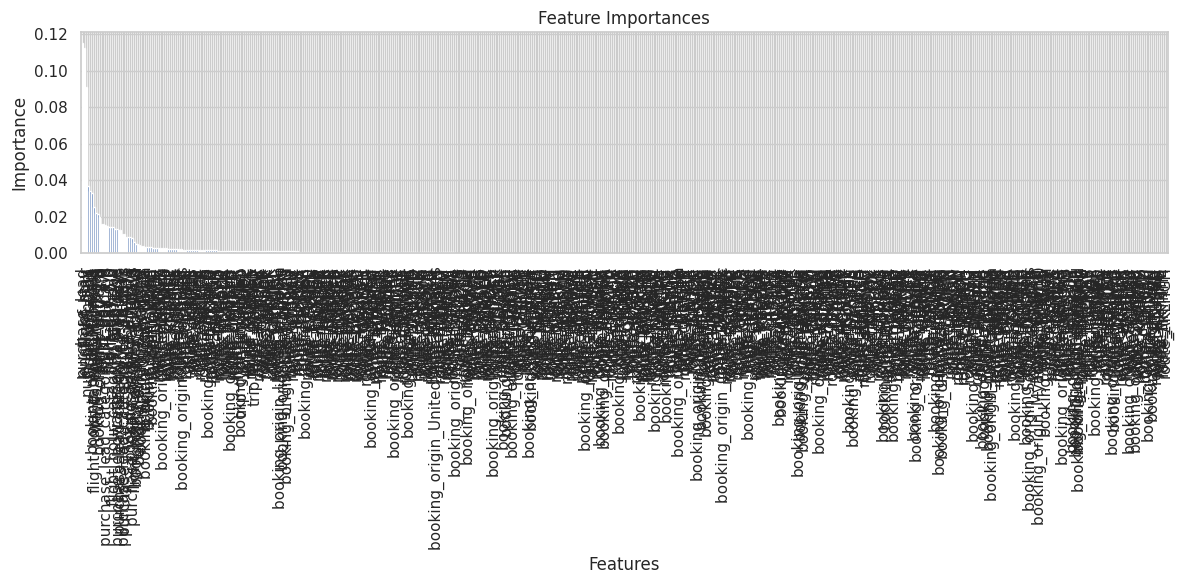

In [44]:

# Create a bar plot of feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

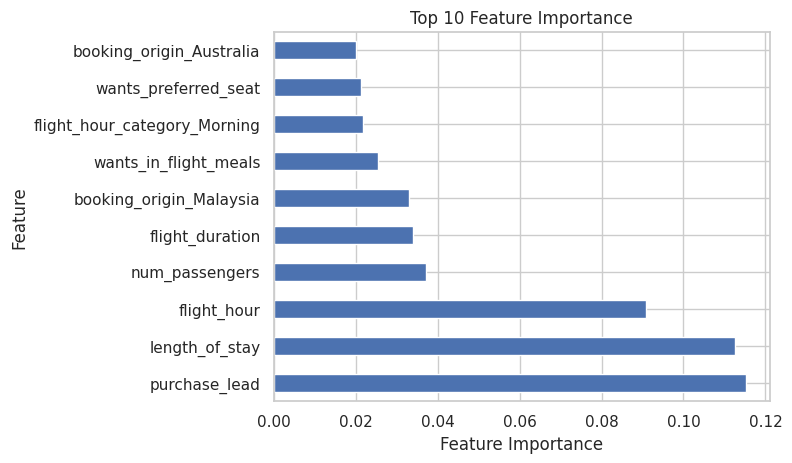

In [46]:
# Feature Importance Plot
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')  # Top 10 features
plt.title('Top 10 Feature Importance')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()